# Quantitative Ignite program reports

**HOW TO USE THIS JUPYTER NOTEBOOK:** highlight the cell by clicking on it. You should see a green or blue box surround it. Then hold the Shift key and press Enter. You should see the highlight box move on to the next cell, and it will print or plot whatever the code says to do.
Try it here. Click on the gray text box below to highlight the cell, then hold Shift and press Enter.

In [1]:
print("Hello world!")

Hello world!


If it says **Hello world!** to you below the gray cell, it worked!

## Import statements, classes, and methods. 
Run these (Shift, Enter) then keep going. They shouldn't spit anything out at you. If they do, tell Abbie.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
import ipywidgets as widgets
import traitlets
from IPython.display import display
from tkinter import Tk, filedialog

In [3]:
def clean_up_df(raw_df):
    """ 
    This method takes a dataframe with program information like Name, Location, Date, Time, Capacity, 
    and two rows for Attended, one with a number for 'Yes' and another with a number for 'No'
    """
    clean_df = pd.DataFrame(columns=('Name', 'Series', 'Location', 'Date', 'Time', 'Day', 
                                         'Capacity', 'Preregistered', 'Attended', 'Percentage'))
    clean_df['Name'] = raw_df['Name'].unique()
    for i in range(len(clean_df)):
        namemask = raw_df.where(raw_df['Name'] == clean_df['Name'][i])
        fvi = namemask.first_valid_index()
        clean_df.loc[i, 'Series'] = namemask['Series'][fvi]
        clean_df.loc[i, 'Location'] = namemask['Location'][fvi]
        clean_df.loc[i, 'Date'] = pd.to_datetime(namemask['Date'][fvi])
        clean_df.loc[i, 'Time'] = namemask['Time'][fvi]
        clean_df.loc[i, 'Capacity'] = namemask['Capacity'][fvi]
        yes_fvi = namemask.where(namemask['Attended'] == "Yes").first_valid_index()
        if yes_fvi == None:
            clean_df.loc[i,'Attended'] = 0
        else:
            clean_df.loc[i, 'Attended'] = namemask['Number'][yes_fvi]
        no_fvi = namemask.where(namemask['Attended'] == "No").first_valid_index()
        if no_fvi == None:
            clean_df.loc[i, 'Preregistered'] = clean_df['Attended'][i]
        else:
            clean_df.loc[i, 'Preregistered'] = clean_df['Attended'][i] + namemask['Number'][no_fvi]
                                                                                        
    clean_df['Percentage'] = clean_df['Attended'] / clean_df['Preregistered']
    clean_df.sort_values(by="Date", inplace=True)
    clean_df['Day'] = [j.strftime('%a') for j in clean_df['Date']]
    return clean_df

In [4]:
def convert_yesno_to_bool(yesno):
    """ This method converts 'yes' and 'no' in an Altru excel file to boolean values."""
    if yesno.casefold() == "yes".casefold():
        return True
    elif yesno.casefold() == "no".casefold():
        return False
    else:
        return np.nan

In [5]:
def get_ci90(df, groupbything, columnthing):
    """ This method gets the 90% confidence interval for errors on a distribution. 
    Need to use with errorbar=('ci', 90) in the plots!"""
    n = len(df)
    means = df.groupby(groupbything, observed=False)[columnthing].mean()
    print("Means:")
    print(means)
    stddevs = df.groupby(groupbything, observed=False)[columnthing].std()
    ci90 = 1.645 * (stddevs / np.sqrt(n))
    print("90% errors:")
    print(ci90)

## Run the cell below, then click the button to select your data file to load. 

The code expects an .xlsx data file made in Altru with the 'Program Query: Food Fight!' ad-hoc query. This file makes columns for the program name, program location, program date and time, participant capacity as specified in Altru, number of spaces still available, then two rows for each program: one with the number of pre-registrants who attended, and one with the number of pre-registrants who did not.

Run this next cell to assign that file name to a variable and read in the excel file, then make a Pandas Dataframe called `programs` with the cleaned data. It will print basic information about the `programs` dataframe.

In [6]:
# program_xlsx_file = button1.files[0]
prefix = "ignite-y2"
program_xlsx_file = "./%s_programs.xlsx" % prefix
raw_program_data = pd.read_excel(program_xlsx_file, engine='openpyxl')
if len(raw_program_data) % 2 != 0:
    print("WARNING: There are an odd number of lines in the program query data file. Please check the file in Excel to ensure that each program is listed twice, once with 'No' and once with 'Yes'. If you're missing a 'Yes' line (because nobody attended), copy the 'No' line, change 'No' to 'Yes', and change 'Number' to 0, and save the changes.")
else:
    programs = clean_up_df(raw_program_data)
    print(programs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           2 non-null      object
 1   Series         2 non-null      object
 2   Location       2 non-null      object
 3   Date           2 non-null      object
 4   Time           2 non-null      object
 5   Day            2 non-null      object
 6   Capacity       2 non-null      object
 7   Preregistered  2 non-null      object
 8   Attended       2 non-null      object
 9   Percentage     2 non-null      object
dtypes: object(10)
memory usage: 292.0+ bytes
None


If it's throwing an error, check the program query data file that each program has two lines, a line with "no" and a line with "yes". If you're missing a "yes" line (because nobody attended), copy the "no" line, change "no" to "yes", and change "number" to "0".

In [7]:
display(programs)

,Name,Series,Location,Date,Time,Day,Capacity,Preregistered,Attended,Percentage
0,Ignite Talks MSU 3,CoLab Studio,311 Abbot,2024-10-30 00:00:00,7:00 PM,Wed,145.0,144.0,91.0,0.631944
1,Ignite Talks MSU 4,CoLab Studio,311 Abbot,2025-02-26 00:00:00,7:00 PM,Wed,100.0,102.0,69.0,0.676471


If you have cancelled or postponed programs (or other reasons why the attendance percentage would be Not a Number), filter those out of what's going to be plotted.

In [8]:
nan_idx = programs['Percentage'].isnull()
programs = programs.loc[~nan_idx]

If the program series is ongoing, filter out the ones that haven't happened yet.

## Let's get some basic numbers!

In [9]:
display(programs[['Name', 'Percentage', 'Attended']])

,Name,Percentage,Attended
0,Ignite Talks MSU 3,0.631944,91.0
1,Ignite Talks MSU 4,0.676471,69.0


## Program location

Rank the locations by number of programs held there.

In [10]:
loc_cats = programs['Location'].value_counts(ascending=False, dropna=True).index
programs['Location'] = pd.Categorical(programs['Location'], categories=loc_cats, ordered=True)

How was attendance of programs based on their location?

In [11]:
programs.groupby('Location', observed=False, dropna=True)['Percentage'].mean()

Location
311 Abbot    0.654208
Name: Percentage, dtype: object

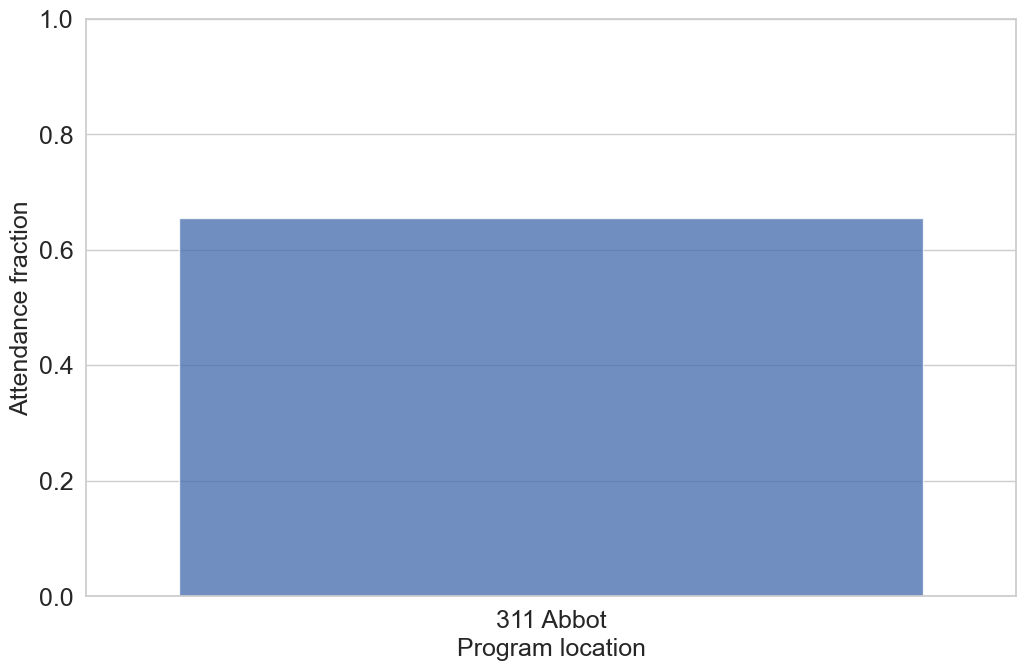

In [12]:
fig, ax = plt.subplots(figsize=(12,7.5))
sns.set_palette('deep')
fig = sns.barplot(data=programs, x='Location', y='Percentage', palette='deep', 
                  hue='Location', saturation=1, alpha=0.8, errorbar=None)
ax.set(xlabel="Program location", ylabel="Attendance fraction", ylim=(0,1))
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
# fig.figure.savefig("./%s_program_location_bar.png" % prefix, bbox_inches='tight')
plt.show()

# Program attendees

Now we can get nitty-gritty. Let's load in the data file with all the registrants for each program.

**VERY IMPORTANT NOTE:** You need to open the excel file and double-check that the non-MSU affiliation says "Not MSU" instaed of "None". Otherwise, having no MSU affiliation gets merged with the people for whom we don't have that information. If needed, do find-replace IN EXCEL to switch "None" to "Not MSU".

In [13]:
reg_xlsx_file = "./%s_registrants.xlsx" % prefix
registrants = pd.read_excel(reg_xlsx_file, engine='openpyxl', converters={'Attended': convert_yesno_to_bool})
display(registrants.info())

# Only keep the programs we used above, since we did some filtering before.
registrants = registrants[registrants['Program name'].isin(programs['Name'].unique().tolist())]

## Shortening location names
registrants['MSU affiliation'] = registrants['MSU affiliation'].fillna("N/A")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Visitor name      246 non-null    object
 1   Attended          246 non-null    bool  
 2   MSU affiliation   243 non-null    object
 3   ZIP code          201 non-null    object
 4   Program name      246 non-null    object
 5   Program location  246 non-null    object
 6   Host name         89 non-null     object
 7   Number of guests  246 non-null    int64 
 8   Notes             30 non-null     object
dtypes: bool(1), int64(1), object(7)
memory usage: 15.7+ KB


None

In [14]:
print(registrants['Program name'].unique())

['Ignite Talks MSU 3' 'Ignite Talks MSU 4']


We can assign a preferred order to display the MSU affiliations.

In [15]:
affil_cats = ['Student', 'Faculty/Staff', 'Alum', 'Parent/Family', 'Not MSU', 'N/A']
registrants['MSU affiliation'] = pd.Categorical(registrants['MSU affiliation'], categories=affil_cats, ordered=True)

In [16]:
print(len(registrants))
print(sum(registrants['Attended']))

246
160


Remove CoLab Studio, since that's our generic host for walk-ins. (I tried just removing its affiliation, but that threw errors down below with the `hosts` dataframe).

In [17]:
colab_idx = ["CoLab Studio".casefold() in item.casefold() for item in registrants['Visitor name']]
registrants.loc[colab_idx, 'MSU affiliation'] = np.nan

In [18]:
print(len(registrants))
print(sum(registrants['Attended']))

246
160


In [19]:
display(registrants.groupby('Program name', observed=False)['Attended'].sum())

Program name
Ignite Talks MSU 3    91
Ignite Talks MSU 4    69
Name: Attended, dtype: int64

In [20]:
sns.set_style('whitegrid')

In [21]:
registrants['MSU affiliation'] = pd.Categorical(registrants['MSU affiliation'], categories=affil_cats, ordered=True)

for i in range(len(programs['Name'])):
    display(programs.loc[i,'Name'])
    prog_loc = registrants['Program name'].str.contains(programs.loc[i, 'Name'], case=False)

'Ignite Talks MSU 3'

'Ignite Talks MSU 4'

## MSU affiliation

Let's clean the registrant data and make a new dataframe where each individal is listed once, and we sum the number of pre-registrations and attendances they had.

In [22]:
reg_by_name = pd.DataFrame(columns=('Visitor name', 'Attended', 'Preregistered', 'Percentage', 'Host name', 'MSU affiliation'))
reg_by_name['Visitor name'] = registrants['Visitor name'].unique()
nas_with_other = 0
for i in range(len(reg_by_name['Visitor name'])):
    appearances = registrants['Visitor name'].values == reg_by_name.loc[i, 'Visitor name']
    reg_by_name.loc[i, 'Preregistered'] = sum(appearances) # sum of times it appears in the whole registrants list, plus guests
    reg_by_name.loc[i, 'Attended'] = sum(registrants.loc[appearances, 'Attended'])#sum of attended where name == visitors name
    affil = registrants.loc[appearances, 'MSU affiliation'].unique()
    if len(affil) > 1 and "N/A" in affil:
        reg_by_name.loc[i, 'MSU affiliation'] = np.delete(affil, np.where(affil == 'N/A'))[0]
        nas_with_other += 1
    else:
        reg_by_name.loc[i, 'MSU affiliation'] = affil[0]
reg_by_name['Percentage'] = reg_by_name['Attended'] / reg_by_name['Preregistered']
reg_by_name['MSU affiliation'] = pd.Categorical(reg_by_name['MSU affiliation'], categories=affil_cats, ordered=True)

In [23]:
tot_reg = sum(reg_by_name['Preregistered'])
uniq_reg = len(reg_by_name)
tot_att = sum(reg_by_name['Attended'])
mult_attend = reg_by_name.iloc[np.where(reg_by_name['Attended'] > 1)[0]]
#display(mult_attend)
attended_once = len(np.where(reg_by_name['Attended'] == 1)[0])
#print(attended_once)
all_guests = np.where(mult_attend['Visitor name'].str.contains("Guest")) 
not_guests = np.where(mult_attend['Visitor name'].str.contains("Guest") == False)
repeat_attender = len(mult_attend.iloc[not_guests])
#print(repeat_attender)
sum_guests = sum(mult_attend['Attended'].iloc[all_guests]) # assume all guests are unique attendees
#print(sum_guests)             
uniq_att = attended_once + repeat_attender + sum_guests
#print(uniq_att)

In [24]:
affil_gb = reg_by_name.groupby('MSU affiliation', observed=False)

In [25]:
for affil in affil_cats:
    print("%d %s (%d pre-registrants; %.0f%% attendance)" % (affil_gb['Attended'].get_group(affil).sum(), 
                                                             affil,
                                                             affil_gb['Preregistered'].get_group(affil).sum(), 
                                                             affil_gb['Percentage'].get_group(affil).mean()*100))

101 Student (141 pre-registrants; 72% attendance)
26 Faculty/Staff (44 pre-registrants; 57% attendance)
10 Alum (19 pre-registrants; 47% attendance)
14 Parent/Family (23 pre-registrants; 62% attendance)
9 Not MSU (14 pre-registrants; 62% attendance)
0 N/A (3 pre-registrants; 0% attendance)


In [41]:
print("\tPre-registrants by MSU affiliation:")
display(affil_gb['Preregistered'].sum())

	Pre-registrants by MSU affiliation:


MSU affiliation
Student          141
Faculty/Staff     44
Alum              19
Parent/Family     23
Not MSU           14
N/A                3
Name: Preregistered, dtype: object

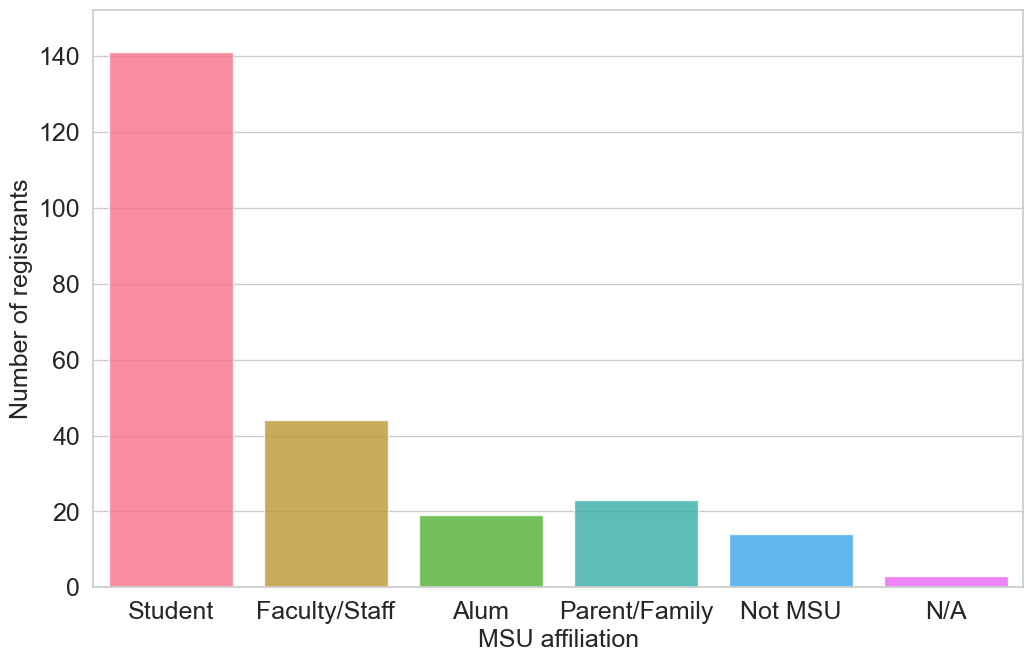

In [42]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(12,7.5))
sns.set_palette("husl")
fig = sns.barplot(data=reg_by_name, x='MSU affiliation', y='Preregistered', palette='husl', 
                  hue='MSU affiliation', estimator=sum, saturation=1, alpha=0.8, err_kws={'linewidth': 0})
ax.set(xlabel="MSU affiliation", ylabel="Number of registrants")
ax.get_legend().remove()
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
fig.figure.savefig("./%s_pre-reg_affil_bar.png" % prefix, bbox_inches='tight')
plt.show()

In [43]:
print("\tAttendees by MSU affiliation:")
display(affil_gb['Attended'].sum())

	Attendees by MSU affiliation:


MSU affiliation
Student          101
Faculty/Staff     26
Alum              10
Parent/Family     14
Not MSU            9
N/A                0
Name: Attended, dtype: object

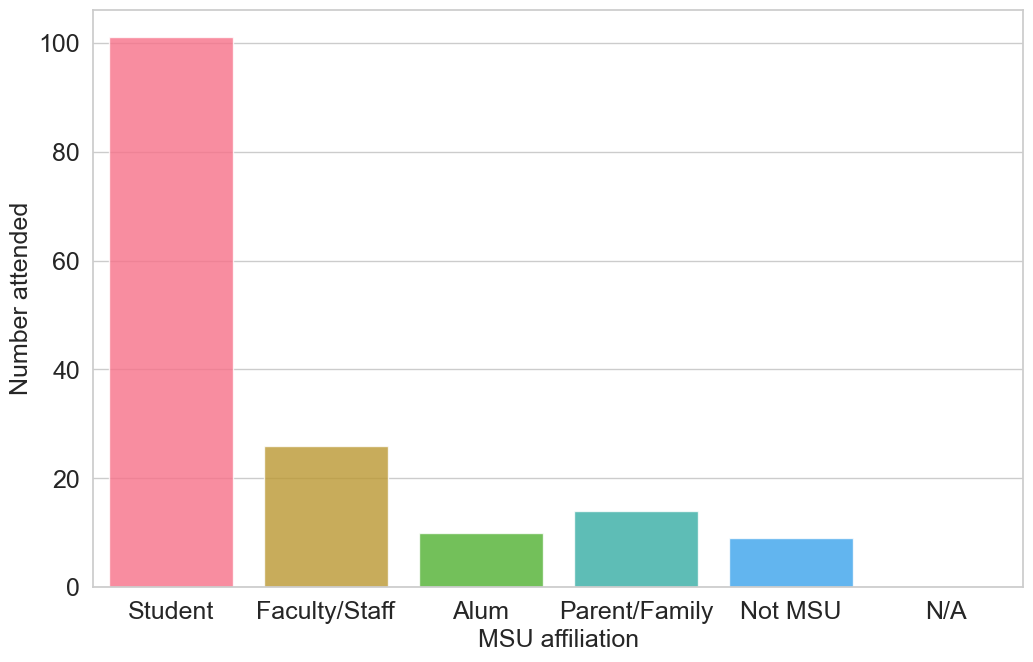

In [44]:
fig, ax = plt.subplots(figsize=(12,7.5))
fig = sns.barplot(data=reg_by_name, x='MSU affiliation', y='Attended', palette='husl', 
                  hue='MSU affiliation', estimator='sum', saturation=1, alpha=0.8, errorbar=None)
ax.set(xlabel="MSU affiliation", ylabel="Number attended")
ax.get_legend().remove()
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
fig.figure.savefig("./%s_attend_affil_bar.png" % prefix, bbox_inches='tight')
plt.show()

In [45]:
display(affil_gb['Percentage'].mean())

MSU affiliation
Student          0.715328
Faculty/Staff    0.571429
Alum             0.470588
Parent/Family    0.619048
Not MSU          0.615385
N/A                   0.0
Name: Percentage, dtype: object

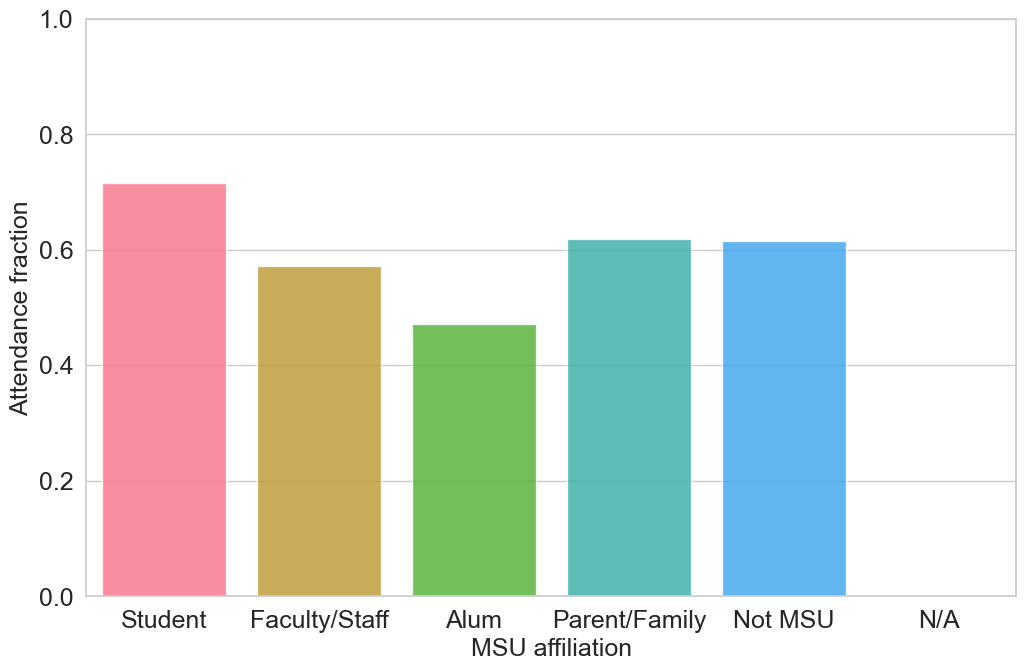

In [46]:
fig, ax = plt.subplots(figsize=(12,7.5))
fig = sns.barplot(data=reg_by_name, x='MSU affiliation', y='Percentage', palette='husl', 
                  hue='MSU affiliation', saturation=1, alpha=0.8, errorbar=None)
ax.set(xlabel="MSU affiliation", ylabel="Attendance fraction", ylim=(0,1))
ax.get_legend().remove()
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
fig.figure.savefig("./%s_percent_affil_bar.png" % prefix, bbox_inches='tight')
plt.show()